# 07_降维技术-核PCA

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今天咱们聊聊降维技术中的**核PCA**\~

核PCA（Kernel Principal Component Analysis）是一种改进版的主成分分析（PCA），它主要用来处理那些传统PCA难以应对的“非线性”数据问题。

首先，什么是降维？

降维就是把数据的维度（变量数量）降低，但尽量保留数据中最重要的信息。比如，你可以把描述一个物体的几十个参数缩减为几个最能代表它特征的参数。

**为什么需要降维？**：

- **简化数据**：帮助我们更容易理解和处理数据。
- **去除噪声**：滤掉一些不重要的、干扰的信息。
- **可视化**：有时候我们希望把高维数据投影到二维或三维空间中，这样就可以画图观察数据分布。

传统PCA通过一种数学方法找出数据中“方向”最多变化的方向（也就是“主成分”）。

它是个线性方法，也就是说，它假设数据主要变化是在直线方向上的。

现在的问题是：如果数据的本质关系是非线性的（比如数据分布呈现一个弯曲或复杂的形状），传统PCA就不太合适，因为它只能捕捉线性关系。

#### 核PCA的核心思路

**非线性映射**：

- 核PCA的“核”指的是一个核函数（Kernel Function）。核函数可以把原始数据通过一个非线性变换映射到一个新的高维空间。
- 在这个高维空间中，原本复杂的非线性结构可能会变成线性结构，从而我们可以像使用传统PCA那样去找数据的“主要方向”。

**为什么要映射到高维空间？**

- 假设原始数据在平面上呈现一个“圆环”形状，在二维中很难找到一个直线来有效描述数据的变化。
- 但如果把数据映射到三维空间，这个圆环可能就会“展开”成一个平面的数据，这时候使用PCA提取主成分就能奏效。

**核技巧（Kernel Trick）**：

- 一个关键在于，我们不需要明确地计算这些高维空间中的映射数据（那样计算量很大），而是利用“核函数”直接计算数据之间的相似度（内积）。
- 这种方法让我们能够“间接地”在高维空间中进行PCA操作，而不必花大量资源计算高维坐标。

举个直观的例子：当你有一张皱巴巴的纸，它在二维平面上看起来很混乱，难以看出整体的模式。

- **传统PCA**就像试图用直尺划分纸上的直线方向，找出数据最显著的直线趋势。但如果纸张的褶皱使得数据不再是直线状，这个方法就力不从心了。
- **核PCA**则是先将这张皱巴巴的纸“拉平”到一个新的空间，这个过程通过某种“魔法”（核函数）实现，数据在新空间中显得更简单、更规则。然后，在新空间里找出最主要的方向，再将这些方向“映射”回原来的数据分析中。

## 原理详解

整体来看，我们从传统PCA出发，再引入映射到高维特征空间以及使用核函数（kernel trick）的思想，最终实现对非线性数据的降维。

### 1. 传统PCA的数学原理回顾

对于一个数据集


$$
X = \{ \mathbf{x}_1, \mathbf{x}_2, \dots, \mathbf{x}_N \}, \quad \mathbf{x}_i \in \mathbb{R}^d,
$$


我们通常先对数据进行中心化处理（均值为零），然后计算协方差矩阵


$$
C = \frac{1}{N} \sum_{i=1}^N \mathbf{x}_i \mathbf{x}_i^T.
$$


PCA的目标是求解协方差矩阵的特征值和对应的特征向量：


$$
C \mathbf{v} = \lambda \mathbf{v}.
$$


从而选择较大的特征值对应的特征向量作为主要的投影方向，实现降维。

### 2. 核PCA的基本思想

在很多实际问题中，数据中存在非线性关系，直接利用线性PCA难以提取有用的信息。核PCA的基本思路是：

1. **非线性映射**  
定义一个非线性映射：  
$\phi: \mathbb{R}^d \to \mathcal{F},$  
将原始数据映射到一个（可能是无限维的）高维特征空间  
$\phi(\mathbf{x}) \in \mathcal{F}.$  
在该空间中，原本非线性的结构可能转化为线性结构。
2. **在高维特征空间内进行PCA**  
在映射后的空间中，数据经过中心化后，其协方差矩阵为  
$C_{\phi} = \frac{1}{N} \sum_{i=1}^N \phi(\mathbf{x}_i) \phi(\mathbf{x}_i)^T.$  
我们希望求解  
$C_{\phi} \mathbf{v} = \lambda \mathbf{v}, \quad \mathbf{v} \in \mathcal{F}.$
3. **核技巧（Kernel Trick）**  
为了避免显式计算$\phi(\mathbf{x})$（特别是当$\mathcal{F}$的维度非常高或无限维时），我们利用核函数满足  
$k(\mathbf{x}_i, \mathbf{x}_j) = \langle \phi(\mathbf{x}_i), \phi(\mathbf{x}_j) \rangle.$  
这样可以直接在原始数据中计算内积结果，从而间接完成高维空间的计算。

### 3. 数学推导与公式

#### 数据中心化

在高维特征空间中，为了进行PCA，我们需要对数据进行中心化，即：


$$
\widetilde{\phi}(\mathbf{x}_i) = \phi(\mathbf{x}_i) - \frac{1}{N} \sum_{j=1}^N \phi(\mathbf{x}_j).
$$


中心化之后的协方差矩阵为：


$$
C_{\phi} = \frac{1}{N} \sum_{i=1}^N \widetilde{\phi}(\mathbf{x}_i) \widetilde{\phi}(\mathbf{x}_i)^T.
$$


由于直接在高维空间中进行运算非常困难，接下来的推导均以核函数为基础。

#### 求解高维空间特征值问题的代数技巧

假设在$\mathcal{F}$空间中存在特征向量$\mathbf{v}$和对应特征值$\lambda$，满足：


$$
C_{\phi} \mathbf{v} = \lambda \mathbf{v}.
$$


由于$\mathbf{v}$必然位于$\text{span}\{\widetilde{\phi}(\mathbf{x}_1), \widetilde{\phi}(\mathbf{x}_2), \dots, \widetilde{\phi}(\mathbf{x}_N)\}$，可以表示为：


$$
\mathbf{v} = \sum_{i=1}^N \alpha_i \widetilde{\phi}(\mathbf{x}_i).
$$


将上式代入特征分解中，有：


$$
\begin{aligned}C_{\phi} \mathbf{v} &= \frac{1}{N} \sum_{j=1}^N \widetilde{\phi}(\mathbf{x}_j) \left\langle \widetilde{\phi}(\mathbf{x}_j), \sum_{i=1}^N \alpha_i \widetilde{\phi}(\mathbf{x}_i) \right\rangle \\&= \frac{1}{N} \sum_{j=1}^N \widetilde{\phi}(\mathbf{x}_j) \sum_{i=1}^N \alpha_i \langle \widetilde{\phi}(\mathbf{x}_j), \widetilde{\phi}(\mathbf{x}_i) \rangle \\&= \lambda \sum_{i=1}^N \alpha_i \widetilde{\phi}(\mathbf{x}_i).\end{aligned}
$$


对任意索引选择$\widetilde{\phi}(\mathbf{x}_\ell)$取内积，得到


$$
\frac{1}{N} \sum_{j=1}^N \sum_{i=1}^N \alpha_i \langle \widetilde{\phi}(\mathbf{x}_j), \widetilde{\phi}(\mathbf{x}_i) \rangle \langle \widetilde{\phi}(\mathbf{x}_j), \widetilde{\phi}(\mathbf{x}_\ell) \rangle = \lambda \alpha_\ell.
$$


更简洁的方法是直接构造核矩阵。定义中心化后的核矩阵元素为  
$K_{ij} = \langle \widetilde{\phi}(\mathbf{x}_i), \widetilde{\phi}(\mathbf{x}_j) \rangle,$  
则上面的特征问题可以写成：  
$\frac{1}{N} K \boldsymbol{\alpha} = \lambda \boldsymbol{\alpha},$  
其中$\boldsymbol{\alpha} = (\alpha_1, \alpha_2, \dots, \alpha_N)^T$。

通常将上式写成：  
$K \boldsymbol{\alpha} = N \lambda \boldsymbol{\alpha}.$

这就转化为在核矩阵上的特征分解问题。注意，这里核矩阵$K$必须先经过中心化，具体步骤将在下面的算法流程中说明。

#### 非线性映射的间接处理

在具体计算时，只需要选取合适的核函数$k(\mathbf{x}, \mathbf{y})$，常见的有：

- 高斯核（径向基函数核）  
$k(\mathbf{x}, \mathbf{y}) = \exp\left( -\frac{\|\mathbf{x} - \mathbf{y}\|^2}{2\sigma^2} \right),$
- 多项式核  
$k(\mathbf{x}, \mathbf{y}) = (\langle \mathbf{x}, \mathbf{y} \rangle + c)^d.$

这样可以直接计算核矩阵$K$，而无需显式计算映射$\phi(\cdot)$带来的高维表示。

### 4. 算法流程详细说明

下面给出利用核函数进行PCA的完整算法流程：

#### 步骤 1：数据准备和中心化

**输入数据**

给定数据集 $X = \{\mathbf{x}_1, \mathbf{x}_2, \dots, \mathbf{x}_N\}$。

**非线性映射与中心化**

理论上需要对数据映射到高维空间：  
$\widetilde{\phi}(\mathbf{x}_i) = \phi(\mathbf{x}_i) - \frac{1}{N}\sum_{j=1}^N \phi(\mathbf{x}_j).$  
由于不直接计算$\phi(\mathbf{x})$，我们采用核矩阵中心化的方法（参见步骤 2）。

#### 步骤 2：构造和中心化核矩阵

**计算原始核矩阵**

对于任意$i,j$，先计算  
$K_{ij} = k(\mathbf{x}_i, \mathbf{x}_j) = \langle \phi(\mathbf{x}_i), \phi(\mathbf{x}_j) \rangle.$

**核矩阵中心化**

为了得到中心化后的核矩阵$\widetilde{K}$，利用下列公式：  
$\widetilde{K} = K - \mathbf{1}_N K - K \mathbf{1}_N + \mathbf{1}_N K \mathbf{1}_N,$  
其中$\mathbf{1}_N$为所有元素为 $\frac{1}{N}$ 的 $N \times N$矩阵。这个公式确保所有映射后的数据均值为零，即  
$\frac{1}{N} \sum_{i=1}^N \widetilde{\phi}(\mathbf{x}_i) = 0.$

#### 步骤 3：求解特征值问题

**构造特征值问题**

求解中心化后核矩阵的特征值问题：  
$\widetilde{K} \boldsymbol{\alpha} = N \lambda \, \boldsymbol{\alpha}.$  
这里，$\lambda$为特征值，$\boldsymbol{\alpha}=(\alpha_1, \alpha_2, \dots, \alpha_N)^T$为对应的特征向量。

**特征值分解**

对矩阵$\widetilde{K}$求解特征分解，得到所有特征值和特征向量。通常我们选择前 $m$ 个最大的特征值和对应的特征向量作为主成分。

#### 步骤 4：归一化特征向量

由于推导过程中有下述关系，所得到的特征向量需要归一化以满足  
$\langle \mathbf{v}, \mathbf{v} \rangle = \mathbf{v}^T \mathbf{v} = 1.$  
对于在特征空间中的投影，有归一化条件：  
$\lambda (\boldsymbol{\alpha}^T \boldsymbol{\alpha}) = 1.$  
因此，归一化时常使用  
$\boldsymbol{\alpha} \leftarrow \frac{\boldsymbol{\alpha}}{\sqrt{\lambda}}.$

#### 步骤 5：数据在特征空间中的投影

对于任意新的样本$\mathbf{x}$，在高维空间中对应的映射为$\phi(\mathbf{x})$。将其投影到第 $k$ 个主成分上（由$\mathbf{v}_k$表示），利用核函数间接计算投影系数：


$$
\begin{aligned}(\mathbf{v}_k)_\phi &= \langle \mathbf{v}_k, \phi(\mathbf{x}) - \frac{1}{N}\sum_{j=1}^N \phi(\mathbf{x}_j) \rangle \\&= \sum_{i=1}^N \alpha_{k,i} \langle \widetilde{\phi}(\mathbf{x}_i), \phi(\mathbf{x}) \rangle \\&= \sum_{i=1}^N \alpha_{k,i} \left[k(\mathbf{x}_i, \mathbf{x}) - \frac{1}{N}\sum_{j=1}^N k(\mathbf{x}_j, \mathbf{x})\right].\end{aligned}
$$


这样我们无需直接计算$\phi(\mathbf{x})$即可得到投影值。

核PCA的核心流程可以总结为：

- **映射与中心化**：通过非线性映射$\phi(\cdot)$使数据在高维空间中线性化，但直接计算困难，因此利用核矩阵与中心化技巧；
- **核矩阵构造**：计算核函数$k(\mathbf{x}_i, \mathbf{x}_j)$得到矩阵$K$，并利用矩阵变换得到中心化核矩阵$\widetilde{K}$；
- **特征值分解**：对$\widetilde{K}$进行特征值分解，得到特征值和特征向量，选取主要成分；
- **归一化与投影**：对特征向量归一化，并利用归一化后的结果对新数据进行投影，从而实现降维。

这种方法利用核技巧，使得我们可以间接在一个高维空间中用线性方法提取数据的主要特征，从而捕捉数据中的非线性结构，是处理复杂数据的有力工具。

## 完整案例

下面咱们通过一个 moons 数据集使用核PCA进行降维，并利用该降维结果进行分类及可视化

通过调节核参数（如 gamma）来进行算法优化，并采用网格搜索评估最佳参数选择。

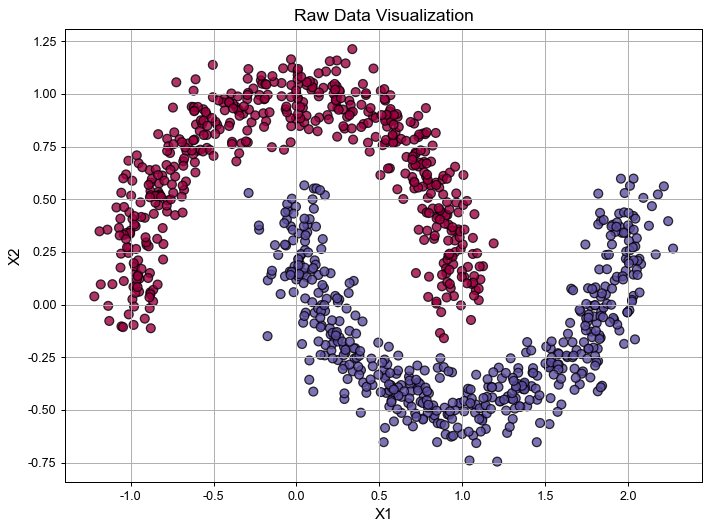

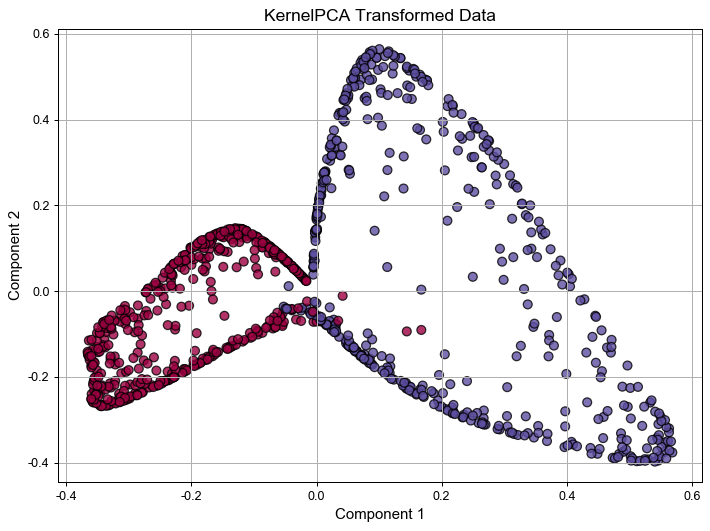

Best Parameters： {'kpca__gamma': np.float64(17.0), 'logistic__C': np.float64(1000.0)}
Best Cross-Validation Accuracy：0.9770


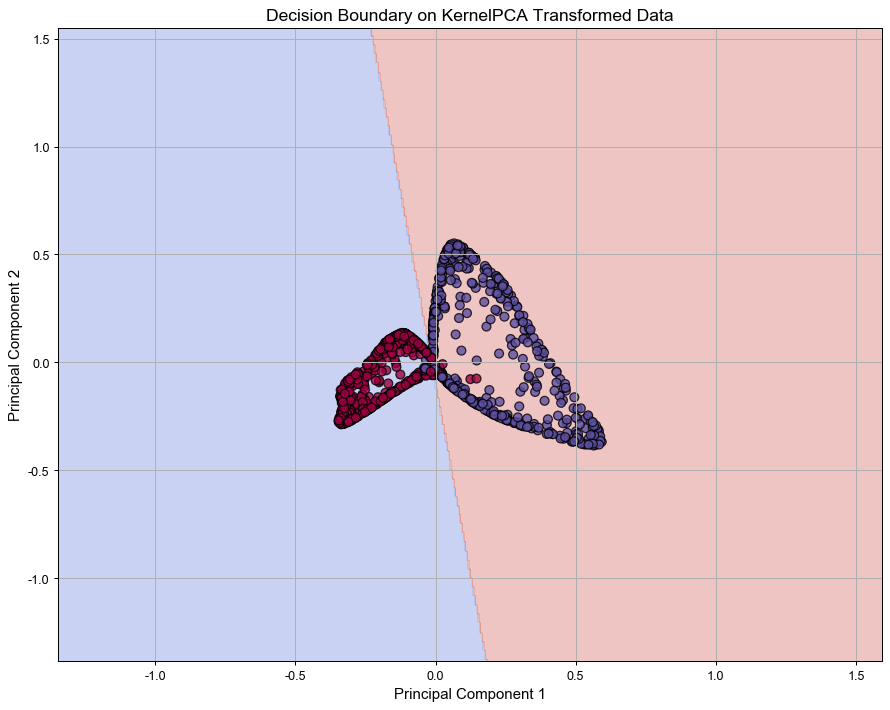

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.decomposition import KernelPCA
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

np.random.seed(42)

# 第一步：生成并可视化原始数据
# 生成非线性数据集 - "moons" 数据集
X, y = make_moons(n_samples=1000, noise=0.1, random_state=42)

# 绘制原始数据散点图
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='Spectral', s=50, edgecolor='k', alpha=0.8)
plt.xlabel("X1", fontsize=12)
plt.ylabel("X2", fontsize=12)
plt.title("Raw Data Visualization", fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()


# 第二步：使用核PCA进行降维并可视化降维结果

# 设置核PCA相关参数，选择 RBF 核作为非线性映射核函数，gamma 参数是需要调节的超参数
kpca = KernelPCA(n_components=2, kernel='rbf', gamma=15, fit_inverse_transform=True, random_state=42)

# 对数据进行降维
X_kpca = kpca.fit_transform(X)

# 绘制降维后的数据散点图
plt.figure(figsize=(8, 6))
plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c=y, cmap='Spectral', s=50, edgecolor='k', alpha=0.8)
plt.xlabel("Component 1", fontsize=12)
plt.ylabel("Component 2", fontsize=12)
plt.title("KernelPCA Transformed Data", fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()


# 第三步：结合监督学习进行核PCA参数优化

# 为了证明降维后的特征对分类任务的帮助，我们将使用逻辑回归对数据进行分类，并通过网格搜索寻找最佳 gamma 参数
# 构建一个包含 KernelPCA 和 LogisticRegression 的 Pipeline（流水线）
pipe = Pipeline([
    ('kpca', KernelPCA(n_components=2, kernel='rbf', random_state=42)),
    ('logistic', LogisticRegression(solver='lbfgs', random_state=42))
])

# 定义参数搜索空间，这里重点对 gamma 参数进行调优，另外也可以调节逻辑回归中的正则化参数 C
param_grid = {
    'kpca__gamma': np.linspace(1, 30, 30),
    'logistic__C': np.logspace(-3, 3, 7)
}

# 使用 StratifiedKFold 保证各折中类别均衡，进行 5 折交叉验证
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 使用 GridSearchCV 寻找最佳参数组合
grid_search = GridSearchCV(pipe, param_grid, scoring='accuracy', cv=cv, n_jobs=1, error_score='raise')
grid_search.fit(X, y)

# 输出最佳参数和对应的分类准确率
print("Best Parameters：", grid_search.best_params_)
print("Best Cross-Validation Accuracy：{:.4f}".format(grid_search.best_score_))


# 第四步：利用最佳参数绘制分类器决策边界图
# 提取最佳参数构建最终模型
best_gamma = grid_search.best_params_['kpca__gamma']
best_C = grid_search.best_params_['logistic__C']

# 构建最终模型
final_kpca = KernelPCA(n_components=2, kernel='rbf', gamma=best_gamma, random_state=42)
X_kpca_best = final_kpca.fit_transform(X)

final_logistic = LogisticRegression(C=best_C, solver='lbfgs', random_state=42)
final_logistic.fit(X_kpca_best, y)

# 构造网格，用于绘制分类器决策边界
x_min, x_max = X_kpca_best[:, 0].min() - 1, X_kpca_best[:, 0].max() + 1
y_min, y_max = X_kpca_best[:, 1].min() - 1, X_kpca_best[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500), np.linspace(y_min, y_max, 500))

# 利用逻辑回归模型预测每个网格点的类别
Z = final_logistic.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 绘制决策边界和数据点
plt.figure(figsize=(10, 8))
# 绘制决策边界等高线图
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
# 绘制数据点
scatter = plt.scatter(X_kpca_best[:, 0], X_kpca_best[:, 1], c=y, cmap='Spectral', s=50, edgecolor='k', alpha=0.8)

plt.xlabel("Principal Component 1", fontsize=12)
plt.ylabel("Principal Component 2", fontsize=12)
plt.title("Decision Boundary on KernelPCA Transformed Data", fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()

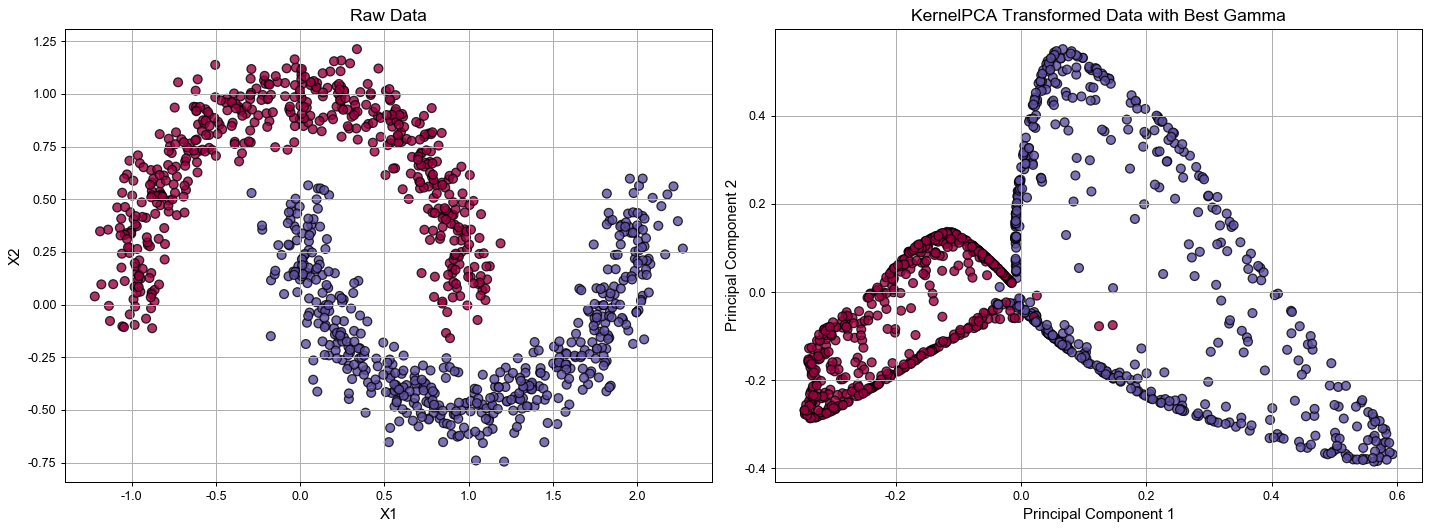

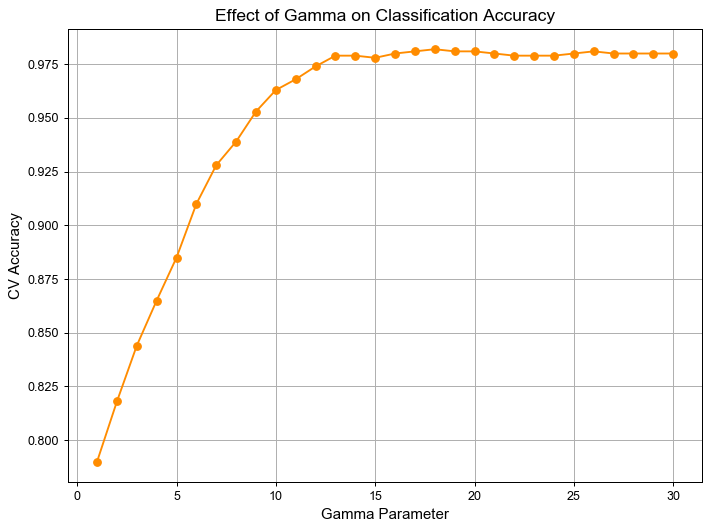

In [3]:
# 第五步：进一步分析降维数据的结构，并对比原始与降维数据
# 为了更直观地理解核PCA对数据结构的影响，我们将原始数据与核PCA降维后数据进行对比绘制
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# 图 1：原始数据
ax[0].scatter(X[:, 0], X[:, 1], c=y, cmap='Spectral', s=50, edgecolor='k', alpha=0.8)
ax[0].set_xlabel("X1", fontsize=12)
ax[0].set_ylabel("X2", fontsize=12)
ax[0].set_title("Raw Data", fontsize=14)
ax[0].grid(True)

# 图 2：核PCA降维后的数据
ax[1].scatter(X_kpca_best[:, 0], X_kpca_best[:, 1], c=y, cmap='Spectral', s=50, edgecolor='k', alpha=0.8)
ax[1].set_xlabel("Principal Component 1", fontsize=12)
ax[1].set_ylabel("Principal Component 2", fontsize=12)
ax[1].set_title("KernelPCA Transformed Data with Best Gamma", fontsize=14)
ax[1].grid(True)

plt.tight_layout()
plt.show()


# 第六步：对算法性能和参数敏感性进行评估
# 通过不同 gamma 参数下的交叉验证准确率来评估算法的性能稳定性
gammas = np.linspace(1, 30, 30)
cv_scores = []

for gamma in gammas:
    kpca_temp = KernelPCA(n_components=2, kernel='rbf', gamma=gamma, random_state=42)
    X_trans = kpca_temp.fit_transform(X)
    clf = LogisticRegression(C=best_C, solver='lbfgs', random_state=42)
    # 使用交叉验证评估模型准确率
    scores = cross_val_score(clf, X_trans, y, cv=cv, scoring='accuracy')
    cv_scores.append(np.mean(scores))

# 绘制 gamma 参数与交叉验证准确率之间的关系曲线
plt.figure(figsize=(8, 6))
plt.plot(gammas, cv_scores, marker='o', color='darkorange')
plt.xlabel("Gamma Parameter", fontsize=12)
plt.ylabel("CV Accuracy", fontsize=12)
plt.title("Effect of Gamma on Classification Accuracy", fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()

1. **数据预处理与可视化**：首先利用 make_moons 数据生成一组非线性数据，通过原始数据散点图展示数据分布，使我们了解到数据存在非线性结构，难以用传统线性降维方法准确描述。

![原文参考图，当前结果见代码输出](attachments/img_012.png)

1. **核PCA降维**：使用核PCA（选择 RBF 核）将数据映射到一个新的特征空间。在这一过程中，参数 gamma 控制非线性映射的“局部性”和“平滑性”，直接影响映射后数据的分布和分类可分性，而 fit_inverse_transform 参数为后续的重构和逆映射提供了可能。

![原文参考图，当前结果见代码输出](attachments/img_013.png)

1. **参数调优与交叉验证**：构建包含核PCA与逻辑回归的流水线，使得整个降维及分类流程连贯进行，并对核PCA的 gamma 参数和逻辑回归的正则化参数 C 同时进行调优。采用 5 折交叉验证评估不同参数组合的稳定性，利用 GridSearchCV 得到最佳参数，确保模型具有良好的泛化性能。
2. **分类器决策边界与结果对比**：根据最佳参数构建最终模型，绘制降维后数据的决策边界图，直观展示模型如何利用核PCA提取的特征对数据进行分类。决策边界清晰显示，说明核PCA有效“展开”了非线性数据，使得简单线性分类器（逻辑回归）也能达到较高的分类准确率。同时，将原始数据与核PCA降维后数据的对比图帮助我们理解核PCA对数据分布结构的重塑作用。

## 模型分析

### 核PCA优缺点

**优点：**

1. **处理非线性关系**：核PCA通过非线性映射将原始数据“展开”，从而可以有效提取隐藏在非线性结构中的主要特征。对于那些具有复杂形状或非线性分布的数据（如双月形、环形结构数据），核PCA比传统线性PCA更能捕获数据内在特性。
2. **无需显式计算高维映射**：利用核技巧，核PCA可以在不直接计算高维空间坐标的情况下，通过核函数计算内积，极大地降低了计算复杂度，同时使得算法可以应用于维数极高甚至无限维的特征空间。
3. **结合监督学习时提升分类效果**：如本案例所示，经核PCA降维后，原本难以区分的非线性数据在新空间中通常变得更易分离，这有助于后续分类器（如逻辑回归）获得更高的准确率，为实际应用提供了更好的特征表示。
4. **适用性广泛**：核PCA既可用于数据降维，也能作为数据预处理、特征提取的有效手段，特别适用于图像处理、基因数据、信号处理等领域的非线性特征提取任务。

**缺点：**

1. **参数选择困难**：核PCA中的核函数类型和其相关参数（如 RBF 核中的 gamma）对降维效果有显著影响。实际应用中往往需要通过调参、交叉验证等方式寻找最佳参数，增加了调试和计算工作量。
2. **计算代价较高**：对于大型数据集，构建核矩阵（其尺寸为 $N \times N$）可能非常消耗内存和计算资源。虽然核技巧避免了直接显式映射，但当样本数量非常大时，计算和存储内积矩阵仍可能成为瓶颈。
3. **缺乏可解释性**：由于数据经过非线性映射至高维空间，再返回低维空间，转换过程较为抽象，不易直观解释各主成分的物理或统计意义，这对部分应用场景可能是个限制。
4. **对噪声和离群点敏感**：如果数据集中存在较多噪声或离群点，核矩阵中部分值可能受到较大影响，从而对降维结果带来不利干扰，需要在应用时对预处理和核函数选择给予足够关注。

### 与相似算法的对比

下表对比了核PCA与几种常见的降维算法，包括传统PCA、t-SNE、UMAP和局部线性嵌入（LLE）等，从数据处理能力、计算复杂度、可解释性和应用场景等方面进行比较：

| 方法 | 数据处理能力 | 计算复杂度 | 可解释性 | 适用场景及优点 | 主要限制 |
|-|-|-|-|-|-|
| **传统 PCA** | 适用于线性数据 | 计算协方差矩阵和特征分解，效率较高 | 较好，主成分意义明确 | 快速、简单，适用于线性关系明显的数据处理 | 无法捕捉非线性结构；对噪声较敏感 |
| **核PCA** | 非线性数据的降维 | 需构造 $N \times N$ 核矩阵，较高 | 较差，降维过程较抽象 | 适合复杂非线性数据，结合核函数后可捕捉隐含的非线性结构 | 参数选择困难；对大数据集计算资源需求高；可解释性较弱 |
| **t-SNE** | 非线性数据的局部结构提取 | 计算量大且不适合大规模数据 | 可视化效果好，但降维映射不唯一 | 专注于局部数据结构，适用于高维数据可视化，能很好地展示聚类情况 | 全局结构不保留；参数调整（如 perplexity）敏感 |
| **UMAP** | 非线性降维（局部与全局兼顾） | 相较 t-SNE 快，效率较高 | 可视化效果好，降维映射更稳定 | 保留数据局部与部分全局结构，适用于大数据集，速度快、扩展性好 | 算法细节较复杂，参数选择对结构保留影响较大 |
| **LLE** | 非线性局部邻域结构 | 算法较复杂，求解局部嵌入映射较耗时 | 降维解释较弱 | 关注局部线性结构，适用于流形假设成立的数据分析 | 对噪声敏感；全局结构难以保持；对数据密度要求较高 |

### 使用建议与讨论

**核PCA的优选场景：**

1. **数据存在明显非线性结构**：当数据本身具有复杂的非线性分布，如双月、螺旋状或环形数据，传统的线性降维方法如 PCA 无法捕捉到这些模式时，核PCA能够将数据映射至高维空间，在那里原始非线性结构可能转化为线性关系，从而实现有效降维。
2. **希望利用简单分类器解决复杂数据问题**：对于一些后续分类任务，本案例展示的做法中，经核PCA变换后的数据使得像逻辑回归这样简单的分类器就能达到较高的分类准确率。此时，核PCA既提升了特征表达能力，也简化了后续处理。
3. **数据量相对较小到中等**：当样本数量不是特别庞大（比如几百到几千个样本），构造和存储核矩阵不会带来太大计算压力，此时使用核PCA可以获得很好的非线性降维效果。

**考虑其他算法的情况：**

1. **大规模数据集**：当数据量达到数万个甚至更多样本时，核PCA构造 $N \times N$ 的核矩阵将变得非常消耗内存和计算资源。此时可以考虑采用 UMAP 或随机投影、近似核方法等降维技术，以在计算效率和降维效果之间取得平衡。
2. **对全局结构要求高的应用**：如果希望不仅能展示局部聚类效果，还需保留数据的全局结构关系，传统的核PCA可能不如 UMAP 或基于变分自编码器（VAE）的降维方法表现得更好。这些方法在保留数据整体结构上有更好的表现。
3. **注重可解释性和稳定性的场景**：由于核PCA的降维映射较为抽象，模型参数对结果的影响较大，在一些需要结果有较好解释性的场景下，传统 PCA 虽然只能捕捉线性关系，但主成分的意义和贡献较为明确，可能更符合要求。此外，对于可视化任务，t-SNE 和 UMAP 提供了直观且稳定的二维或三维表示，常用于探索数据结构和聚类结果。
4. **对噪声敏感的数据**：当数据噪声较多或存在显著离群点时，核PCA在构造核矩阵的过程中可能将噪声也映射到高维空间，从而影响降维效果。在这类情形下，除了结合合适的核参数外，也可以考虑先采用鲁棒的预处理方法或使用对噪声鲁棒性更好的降维算法，如某些稳健的变分方法或基于密度的方法。

### 总结

核PCA在捕捉非线性数据特征、改善后续分类任务上有显著优势，但同时在参数调优、计算效率和可解释性方面存在不足。对于小规模且非线性特征较强的数据集，核PCA是一个非常优选的降维工具；而对于大规模数据、对全局结构要求较高或需要较强可解释性的场景，可以考虑采用传统PCA、t-SNE、UMAP或其他降维方法。